In [3]:
#Importing libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

In [4]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [5]:
transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # transforms.Normalize((0.5,), (0.5,)) # if you want to normlize the data
    # transforms.Lambda(lambda x: x.repeat(3, 1, 1))  # Convert grayscale to RGB
])

In [15]:
MRI_Data_train = datasets.ImageFolder(root='brain_tumor_mris/Training', transform=transforms)
MRI_Data_test = datasets.ImageFolder(root='brain_tumor_mris/Testing', transform=transforms)
MRI_Data_validation = datasets.ImageFolder(root='brain_tumor_mris/Validation', transform=transforms)

In [ ]:
MRI_Data_train

Dataset ImageFolder
    Number of datapoints: 4672
    Root location: brain_tumor_mris/Training
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )

In [ ]:
MRI_Data_train.classes

['glioma', 'meningioma', 'notumor', 'pituitary']

In [18]:
MRI_Data_train = DataLoader(MRI_Data_train, batch_size=32, shuffle=True)
MRI_Data_test = DataLoader(MRI_Data_test, batch_size=32, shuffle=True) 
MRI_Data_validation = DataLoader(MRI_Data_validation, batch_size=32, shuffle=True)

In [23]:
MRI_Data_train.dataset.classes, MRI_Data_test.dataset.classes, MRI_Data_validation.dataset.classes

(['glioma', 'meningioma', 'notumor', 'pituitary'],
 ['glioma', 'meningioma', 'notumor', 'pituitary'],
 ['glioma', 'meningioma', 'notumor', 'pituitary'])

In [30]:
len(MRI_Data_test.dataset)

576

In [32]:
for i , data in enumerate(MRI_Data_train):
    print(i, data[0].shape, data[1].shape)
    print(data)
    break

0 torch.Size([32, 3, 224, 224]) torch.Size([32])
[tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0039, 0.0039, 0.0039,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0039, 0.0039, 0.0039,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0

In [37]:
#Function for showing batches

def show_MRI_batch(dataloader, title="Batch of CT Images"):
    images, labels = next(iter(dataloader))
    fig, axes = plt.subplots(4, 8, figsize=(15, 8))
    fig.suptitle(title)
    
    for i, ax in enumerate(axes.flatten()):
        if i < len(images):
            img = images[i].permute(1, 2, 0)  # Convert tensor image for plotting
            ax.imshow(img)
            ax.set_title(MRI_Data_train.dataset.classes[labels[i]])
            ax.axis('off')
    plt.show()

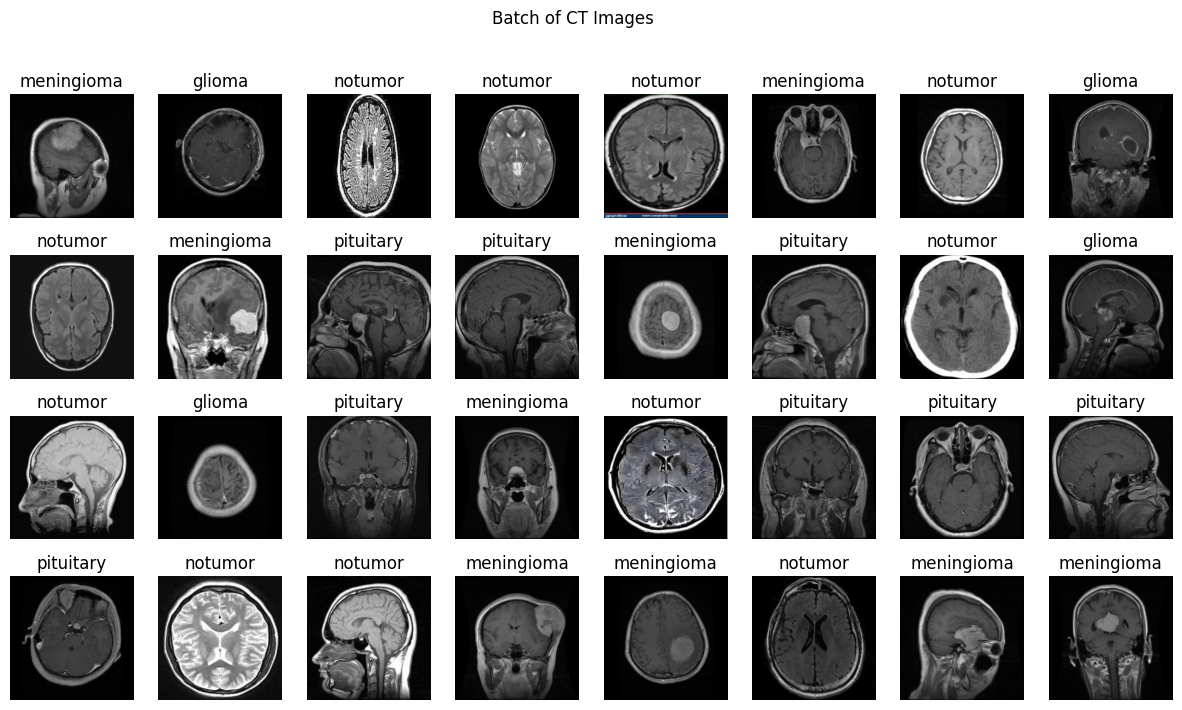

In [38]:
show_MRI_batch(MRI_Data_train)

In [48]:
import torch
import torch.nn as nn

# Magnetic Resonance Imaging CNN Model
class MRIModel(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.layer_stack = nn.Sequential(
            # Conv Layer Block 1
            nn.Conv2d(in_channels=in_channels, out_channels=32, kernel_size=3, stride=1, padding=1),  # 224x224x32
            nn.ReLU(),
            
            # Conv Layer Block 2
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # 224x224x64
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 112x112x64
            
            # Conv Layer Block 3
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),  # 112x112x128
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 56x56x128
            
            # Conv Layer Block 4
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),  # 56x56x256
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 28x28x256
            
            # Conv Layer Block 5
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),  # 28x28x512
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=4, stride=4),  # 7x7x512

            nn.Flatten(),  # 7*7*512 = 25088
            nn.Linear(7 * 7 * 512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.layer_stack(x)

# Instantiate
mri_model = MRIModel(in_channels=3, num_classes=4)
print(mri_model)

MRIModel(
  (layer_stack): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU()
    (13): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (14): Flatten(start_dim=1, end_dim=-1)
    (15): Linear(in_features=25088, out_features=256, bias=True)
    (16): ReLU()
    (17): Dropout(p=0.5, inplace=Fals

In [ ]:
from torchsummary import summary
summary(mri_model , input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
              ReLU-2         [-1, 32, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          18,496
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
         MaxPool2d-8          [-1, 128, 56, 56]               0
            Conv2d-9          [-1, 256, 56, 56]         295,168
             ReLU-10          [-1, 256, 56, 56]               0
        MaxPool2d-11          [-1, 256, 28, 28]               0
           Conv2d-12          [-1, 512, 28, 28]       1,180,160
             ReLU-13          [-1, 512, 28, 28]               0
        MaxPool2d-14            [-1, 51

In [51]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(mri_model.parameters(),lr=0.001)
mri_model=mri_model.to(device)

In [55]:
from tqdm import tqdm

num_epochs = 10
best_val_acc = 0.0

mri_all_labels = []
mri_all_predictions = []

for epoch in range(num_epochs):
    # Training loop
    mri_model.train()
    running_loss = 0.0
    for images, labels in tqdm(MRI_Data_train):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = mri_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation loop
    mri_model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.inference_mode():
        for images, labels in tqdm(MRI_Data_validation):  # Separate validation loader
            images, labels = images.to(device), labels.to(device)
            outputs = mri_model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train Loss: {running_loss / len(MRI_Data_train):.4f}")
    print(f"  Val Loss:   {val_loss / len(MRI_Data_validation):.4f}")
    print(f"  Val Acc:    {val_acc:.2f}%")

    # Save best model (optional)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(mri_model.state_dict(), "best_mri_model.pth")
        print("  ✅ Saved new best model!")


 81%|████████  | 118/146 [11:13<02:39,  5.71s/it]


KeyboardInterrupt: 

In [ ]:
# Final test accuracy
mri_model.eval()
test_correct = 0
test_total = 0

with torch.inference_mode():
    for images, labels in tqdm(MRI_Data_test):  # Final test set
        images, labels = images.to(device), labels.to(device)
        outputs = mri_model(images)
        _, predicted = torch.max(outputs, 1)

        mri_all_labels.extend(labels.cpu().numpy())
        mri_all_predictions.extend(predicted.cpu().numpy())

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

print(f"✅ Final Test Accuracy: {100 * test_correct / test_total:.2f}%")